Standard deviations per variable for engine 1:
altitude     1.953446e-03
mach_nr      2.822825e-04
TRA          0.000000e+00
T2           1.367809e-12
T24          4.867952e-01
T30          5.759776e+00
T50          8.565610e+00
P2           6.589703e-14
P15          3.918202e-14
P30          9.104140e-01
Nf           7.091352e-02
Nc           4.911853e+00
epr          4.452502e-15
Ps30         2.683460e-01
phi          7.491763e-01
NRf          7.696013e-02
NRc          5.563129e+00
BPR          3.412461e-02
farB         1.739259e-17
htBleed      1.475661e+00
Nf_dmd       0.000000e+00
PCNfR_dmd    0.000000e+00
W31          1.669984e-01
W32          1.051013e-01
dtype: float64


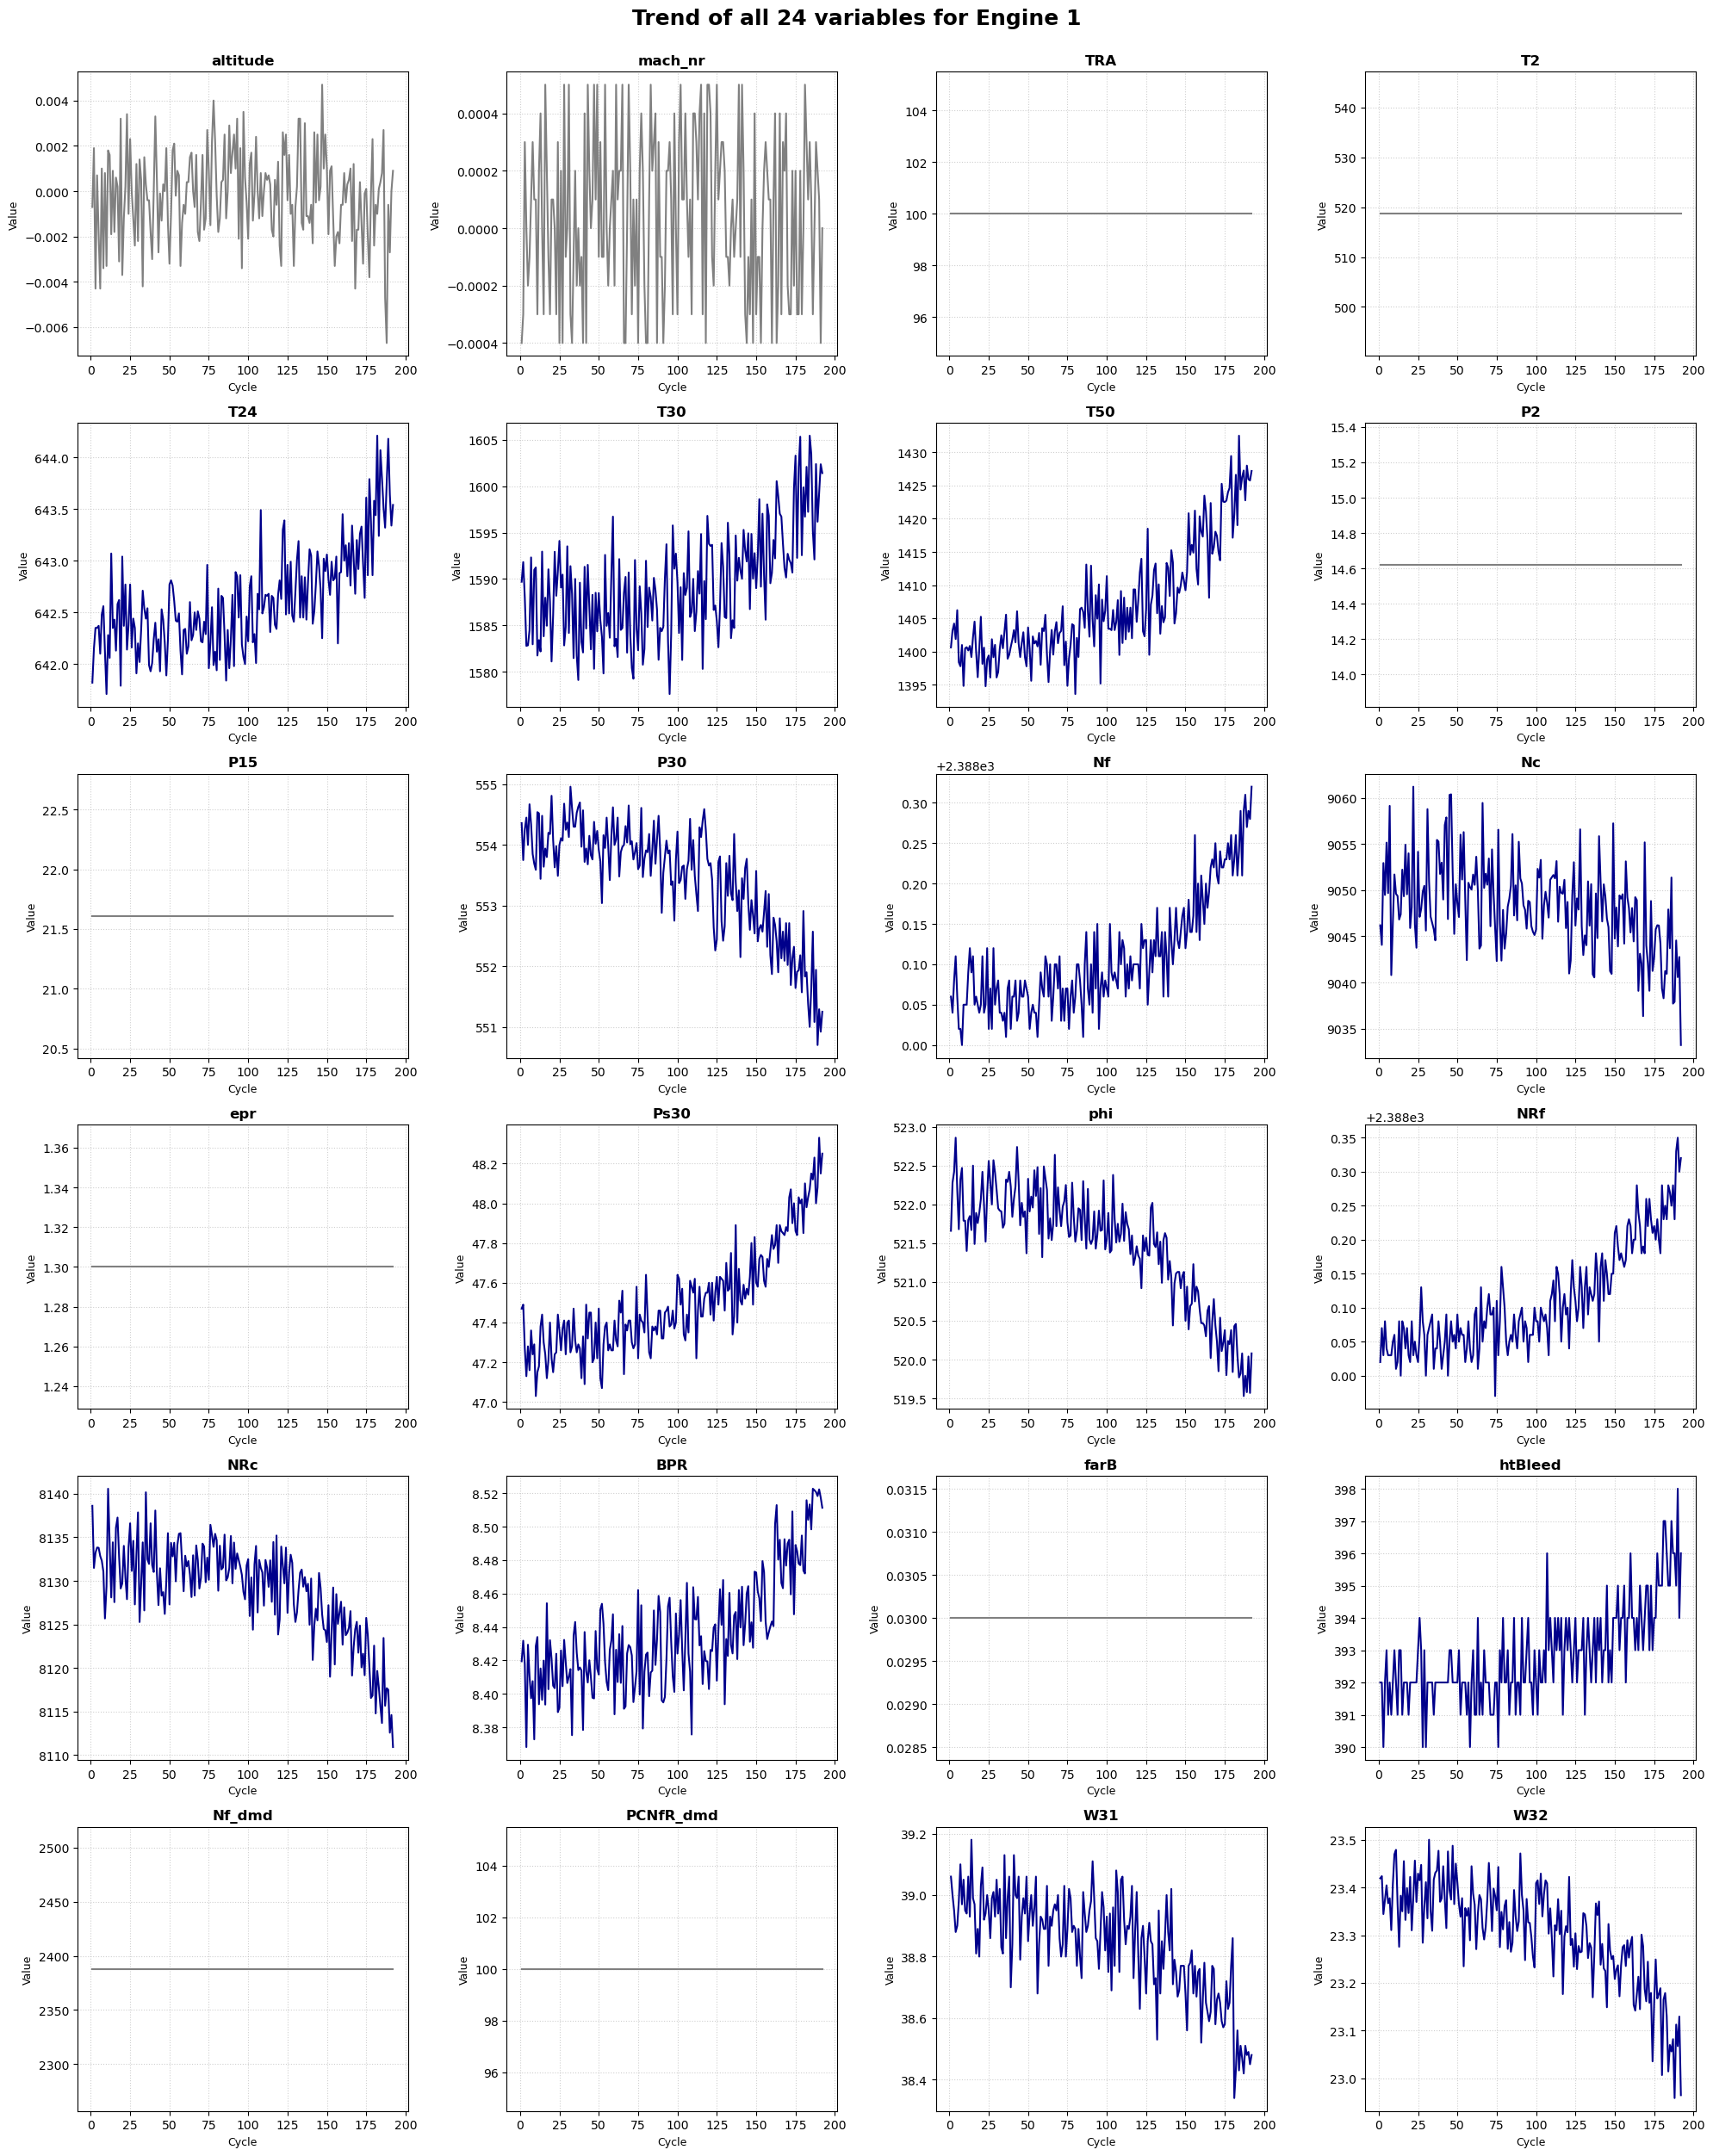

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from import_data import df_train, df_test
import seaborn as sns

engine_1 = df_train[df_train['engine'] == 1]

features_to_plot = ['altitude',  'mach_nr', 'TRA',
                'T2', # total temperature at fan inlet
                'T24',# total temperature at LPC outlet
                'T30', # total temperature at HPC outlet
                'T50', # total temperature at LPT outlet
                'P2', # Pressure at fan inlet
                'P15', #Total pressure in bypass-duct
                'P30', #Total pressure at HPC outlet
                'Nf', #Physical fan speed rpm
                'Nc', #Physical core speed rpm
                'epr', #Engine pressure ratio (P50/P2)
                'Ps30', #Static pressure at HPC outlet
                'phi', #Ratio offuel flow to Ps30
                'NRf', #Corrected fan speed
                'NRc', #Corrected core speed
                'BPR', #Bypass Ratio
                'farB', #Burner fuel-air ratio
                'htBleed', #Bleed Enthalpy
                'Nf_dmd', # Demanded fan speed rpm
                'PCNfR_dmd', #Demanded corrected fan speed rpm
                'W31', #HPT coolant bleed lbm/s
                'W32', #LPT coolant bleed
]

std_devs_m1 = engine_1[features_to_plot].std()
print("Standard deviations per variable for engine 1:")
print(std_devs_m1)

fig, axes = plt.subplots(6, 4, figsize=(20, 25))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    is_constant = engine_1[feature].std() < 0.01
    plot_color = 'grey' if is_constant else 'darkblue'
    
    ax.plot(engine_1['cycle'], engine_1[feature], color=plot_color)
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cycle', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Trend of all 24 variables for Engine 1', fontsize=18, y=1, fontweight='bold')
plt.tight_layout()
plt.show()

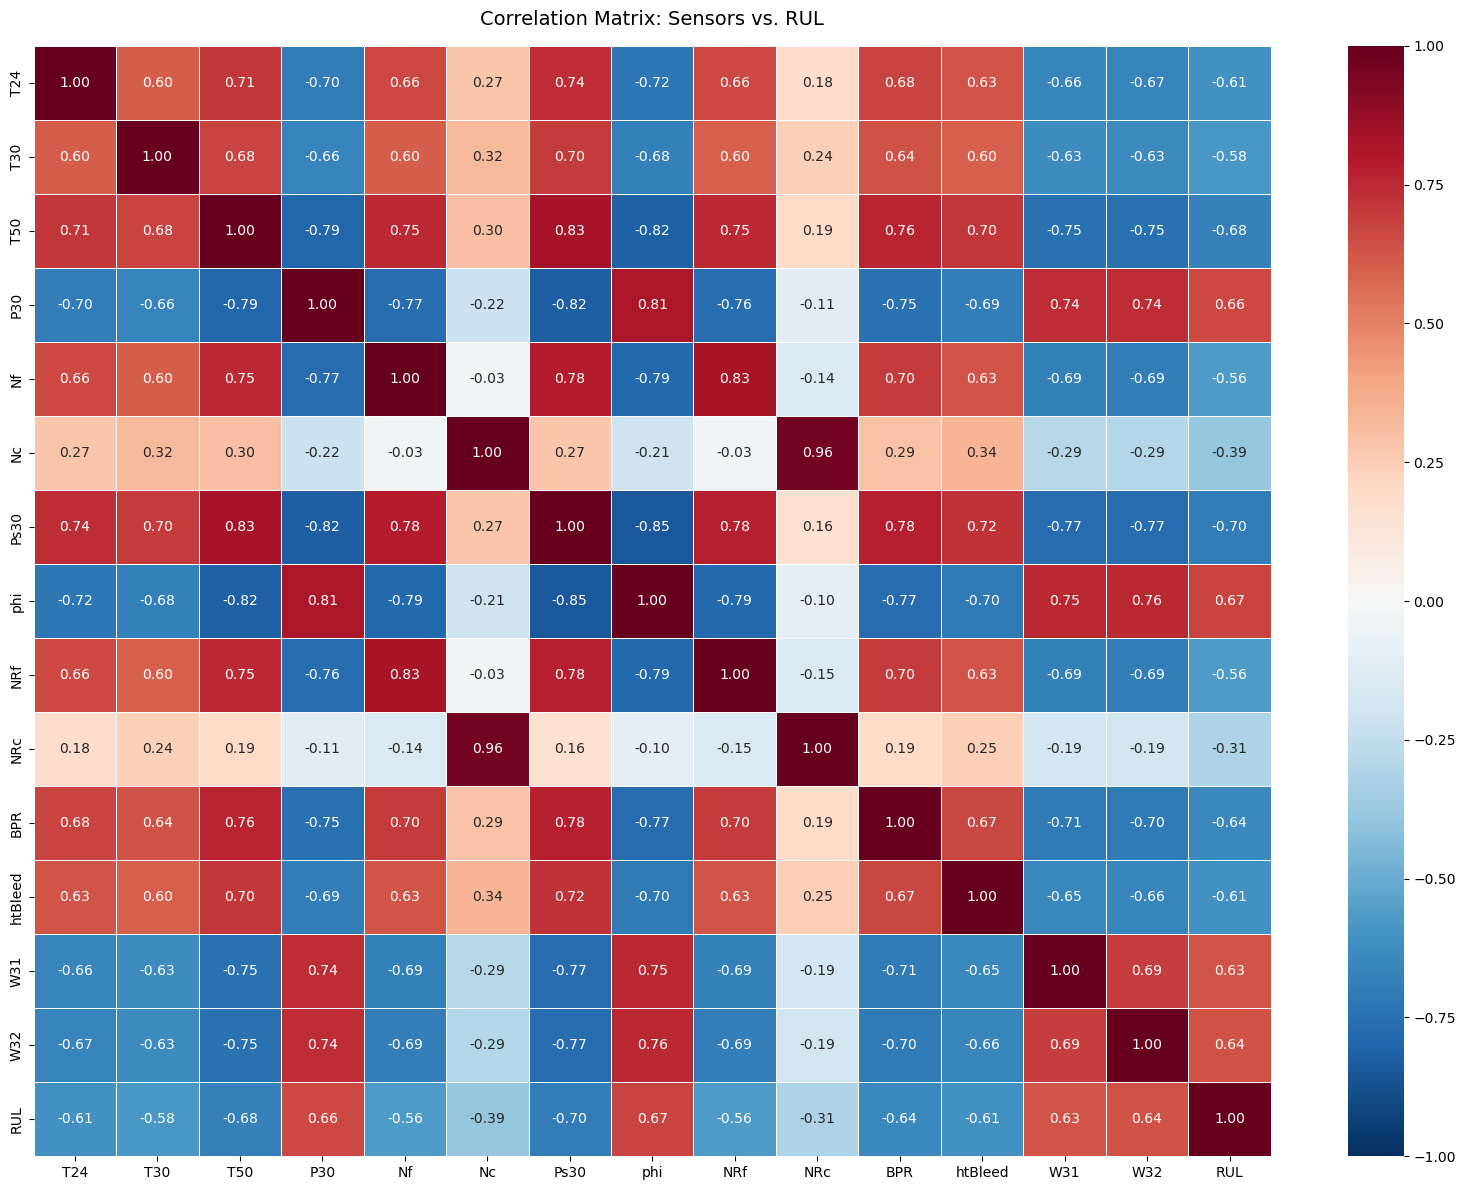

In [2]:
features_to_check = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 
    'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32', 'RUL']
max_cycles_train = df_train.groupby('engine')['cycle'].max().to_dict()
df_train['RUL'] = df_train['engine'].map(max_cycles_train) - df_train['cycle']

corr_matrix = df_train[features_to_check].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Matrix: Sensors vs. RUL', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

# pre-processing
df_train['RUL_capped'] = np.minimum(df_train['RUL'], 125)
scaler = MinMaxScaler(feature_range=(0, 1))
features_for_model = [
    'T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 
    'Ps30', 'phi', 'NRf', 'BPR', 'W31', 'W32']
X_train_scaled = scaler.fit_transform(df_train[features_for_model])
y_train_capped = df_train['RUL_capped'].values

df_test_last = df_test.groupby('engine').last()
X_test_scaled = scaler.transform(df_test_last[features_for_model])


torch.manual_seed(0)

class RULModel(nn.Module):
    def __init__(self, input_dim, output_dim=1, dropout_p=0.2):
        super(RULModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, output_dim)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.leaky_relu(self.fc1(x)); x = self.dropout(x)
        x = self.leaky_relu(self.fc2(x)); x = self.dropout(x)
        x = self.leaky_relu(self.fc3(x)); x = self.dropout(x)
        x = self.leaky_relu(self.fc4(x)); x = self.dropout(x)
        return self.fc5(x)
    

def train_rul_model(X_train, y_train_capped, lr=1e-3, dropout_p=0.2, num_epochs=600, patience=30):
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_capped, dtype=torch.float32).unsqueeze(1)

    model = RULModel(input_dim=X_tensor.shape[1], dropout_p=dropout_p)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    rmse_list = []
    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        y_pred = model(X_tensor)
        loss = criterion(y_pred, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        rmse_list.append(torch.sqrt(loss).item())

        # Early stopping
        if loss.item() < best_loss - 1e-4:
            best_loss = loss.item()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break  # stop early

    return model, rmse_list


def test_rul_model(model, X_test, y_test):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
        predictions = model(X_tensor)
        rmse = torch.sqrt(nn.functional.mse_loss(predictions, y_tensor)).item()
    print(f"RMSE: {rmse:.2f} flight cycles")
    return predictions.numpy(), rmse

# Took too long to train, so I commented it out. 
#
# def train_rul_model(X_train, y_train_capped, lr=1e-3, dropout_p=0.2, num_epochs=600):
#     X_tensor = torch.tensor(X_train, dtype=torch.float32)
#     y_tensor = torch.tensor(y_train_capped, dtype=torch.float32).unsqueeze(1)

#     model = RULModel(input_dim=X_tensor.shape[1], dropout_p=dropout_p)
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr)

#     rmse_list = []
#     for epoch in range(num_epochs):
#         model.train()
#         y_pred = model(X_tensor)
#         loss = criterion(y_pred, y_tensor)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         rmse_list.append(torch.sqrt(loss).item())

#         if (epoch + 1) % 100 == 0:
#             print(f"Epoch [{epoch+1}/{num_epochs}], Train RMSE: {rmse_list[-1]:.2f}")

#     return model, rmse_list


####################

# old code for reference

# class RULModel(nn.Module):
#     def __init__(self, input_dim, output_dim=1):
#         super(RULModel, self).__init__()
#         self.fc1 = nn.Linear(input_dim, 256)
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, 64)
#         self.fc4 = nn.Linear(64, 32)
#         self.fc5 = nn.Linear(32, output_dim)
#         self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)
#         self.dropout = nn.Dropout(p=0.2)

#     def forward(self, x):
#         x = self.leaky_relu(self.fc1(x))
#         x = self.dropout(x)
#         x = self.leaky_relu(self.fc2(x))
#         x = self.dropout(x)
#         x = self.leaky_relu(self.fc3(x))
#         x = self.dropout(x)
#         x = self.leaky_relu(self.fc4(x))
#         x = self.dropout(x)
#         x = self.fc5(x)
#         return x

#  def train_rul_model(X_train, y_train_capped):
#     X_tensor = torch.tensor(X_train, dtype=torch.float32)
#     y_tensor = torch.tensor(y_train_capped, dtype=torch.float32).unsqueeze(1)

#     input_dim = X_tensor.shape[1]
#     output_dim = 1
    
#     lr = 1e-3 
#     num_epochs = 600 

#     model = RULModel(input_dim, output_dim)
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr)

#     rmse_list = []
#     for epoch in range(num_epochs):
#         model.train()
#         y_pred = model(X_tensor)
#         loss = criterion(y_pred, y_tensor)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         rmse_train = torch.sqrt(loss).item()
#         rmse_list.append(rmse_train)

#         if (epoch + 1) % 100 == 0:
#             print(f"Epoch [{epoch+1}/{num_epochs}], Train RMSE: {rmse_train:.2f}")

#     return model, rmse_list


# def test_rul_model(model, X_test_last_cycles, y_test_capped):
#     model.eval()
    
#     X_tensor = torch.tensor(X_test_last_cycles, dtype=torch.float32)
#     y_tensor = torch.tensor(y_test_capped, dtype=torch.float32).unsqueeze(1)

#     with torch.no_grad():
#         predictions = model(X_tensor)
        
#         mse_loss = nn.functional.mse_loss(predictions, y_tensor)
#         rmse_loss = torch.sqrt(mse_loss).item()

#     print(f"Final Test RMSE: {rmse_loss:.2f} flight cycles")
    
#     return predictions.numpy(), rmse_loss


from itertools import product

param_grid = {
    'lr':      [1e-2, 1e-3, 1e-4],
    'dropout': [0.1, 0.2, 0.3],
    'epochs':  [400, 600, 800],
}

gkf = GroupKFold(n_splits=5)
gs_results = []

for lr, dropout, epochs in product(param_grid['lr'],
                                   param_grid['dropout'],
                                   param_grid['epochs']):
    fold_rmses = []
    for fold, (train_idx, val_idx) in enumerate(
            gkf.split(X_train_scaled, y_train_capped,
                      groups=df_train['engine'].values)):

        model_gs, _ = train_rul_model(
            X_train_scaled[train_idx], y_train_capped[train_idx],
            lr=lr, dropout_p=dropout, num_epochs=epochs)

        _, val_rmse = test_rul_model(
            model_gs, X_train_scaled[val_idx], y_train_capped[val_idx])

        fold_rmses.append(val_rmse)

    mean_rmse = np.mean(fold_rmses)
    gs_results.append({'lr': lr, 'dropout': dropout,
                       'epochs': epochs, 'mean_val_rmse': mean_rmse})
    print(f"lr={lr}, dropout={dropout}, epochs={epochs} → mean val RMSE={mean_rmse:.2f}")

# Show sorted results
gs_df = pd.DataFrame(gs_results).sort_values('mean_val_rmse').reset_index(drop=True)
print("\nTop 5 configurations:")
print(gs_df.head())

best = gs_df.iloc[0]
print(f"\nBest: lr={best['lr']}, dropout={best['dropout']}, "
      f"epochs={int(best['epochs'])}, RMSE={best['mean_val_rmse']:.2f}")



RMSE: 20.22 flight cycles
RMSE: 18.81 flight cycles
RMSE: 18.61 flight cycles
RMSE: 17.51 flight cycles
RMSE: 16.43 flight cycles
lr=0.01, dropout=0.1, epochs=400 → mean val RMSE=18.32
RMSE: 20.63 flight cycles
RMSE: 18.86 flight cycles
RMSE: 18.72 flight cycles
RMSE: 17.41 flight cycles
RMSE: 16.60 flight cycles
lr=0.01, dropout=0.1, epochs=600 → mean val RMSE=18.44
RMSE: 20.32 flight cycles
RMSE: 18.78 flight cycles
RMSE: 18.29 flight cycles
RMSE: 17.48 flight cycles
RMSE: 16.57 flight cycles
lr=0.01, dropout=0.1, epochs=800 → mean val RMSE=18.29
RMSE: 20.66 flight cycles
RMSE: 19.02 flight cycles
RMSE: 18.59 flight cycles
RMSE: 17.26 flight cycles
RMSE: 17.15 flight cycles
lr=0.01, dropout=0.2, epochs=400 → mean val RMSE=18.54
RMSE: 20.34 flight cycles
RMSE: 18.98 flight cycles
RMSE: 18.56 flight cycles
RMSE: 17.32 flight cycles
RMSE: 17.46 flight cycles
lr=0.01, dropout=0.2, epochs=600 → mean val RMSE=18.53
RMSE: 20.49 flight cycles
RMSE: 18.85 flight cycles
RMSE: 18.81 flight cycl

In [ ]:


# rmse_values = []
# test_rmse_values = []
# gkf = GroupKFold(n_splits=5)
# for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_scaled, y_train_capped, groups=df_train['engine'].values)):

#     model_fold, rmse_train = train_rul_model(X_train_scaled[train_idx], y_train_capped[train_idx])
#     _, val_rmse = test_rul_model(model_fold, X_train_scaled[val_idx], y_train_capped[val_idx])
#     rmse_values.append(rmse_train)
#     test_rmse_values.append(val_rmse)

# trained_model, _ = train_rul_model(X_train_scaled, y_train_capped)
# true_test_rul = np.loadtxt('RUL_FD001.txt')
# predictions, final_rmse = test_rul_model(trained_model, X_test_scaled, true_test_rul)

rmse_values = []
test_rmse_values = []

for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X_train_scaled, y_train_capped,
                  groups=df_train['engine'].values)):

    model_fold, rmse_train = train_rul_model(
        X_train_scaled[train_idx], y_train_capped[train_idx],
        lr=best['lr'], dropout_p=best['dropout'], num_epochs=int(best['epochs']))

    _, val_rmse = test_rul_model(
        model_fold, X_train_scaled[val_idx], y_train_capped[val_idx])

    rmse_values.append(rmse_train)
    test_rmse_values.append(val_rmse)


trained_model, _ = train_rul_model(
    X_train_scaled, y_train_capped,
    lr=best['lr'], dropout_p=best['dropout'], num_epochs=int(best['epochs']))

true_test_rul = np.loadtxt('RUL_FD001.txt')
predictions, final_rmse = test_rul_model(trained_model, X_test_scaled, true_test_rul)




Epoch [100/600], Train RMSE: 38.49
Epoch [200/600], Train RMSE: 27.11
Epoch [300/600], Train RMSE: 25.57
Epoch [400/600], Train RMSE: 24.81
Epoch [500/600], Train RMSE: 24.28
Epoch [600/600], Train RMSE: 23.66
Final Test RMSE: 20.71 flight cycles
Epoch [100/600], Train RMSE: 37.39
Epoch [200/600], Train RMSE: 26.96
Epoch [300/600], Train RMSE: 25.25
Epoch [400/600], Train RMSE: 24.79
Epoch [500/600], Train RMSE: 23.97
Epoch [600/600], Train RMSE: 23.74
Final Test RMSE: 19.58 flight cycles
Epoch [100/600], Train RMSE: 38.43
Epoch [200/600], Train RMSE: 27.34
Epoch [300/600], Train RMSE: 25.51
Epoch [400/600], Train RMSE: 25.01
Epoch [500/600], Train RMSE: 24.30
Epoch [600/600], Train RMSE: 23.81
Final Test RMSE: 18.77 flight cycles
Epoch [100/600], Train RMSE: 38.55
Epoch [200/600], Train RMSE: 27.59
Epoch [300/600], Train RMSE: 26.18
Epoch [400/600], Train RMSE: 25.28
Epoch [500/600], Train RMSE: 24.71
Epoch [600/600], Train RMSE: 24.30
Final Test RMSE: 17.85 flight cycles
Epoch [100/6

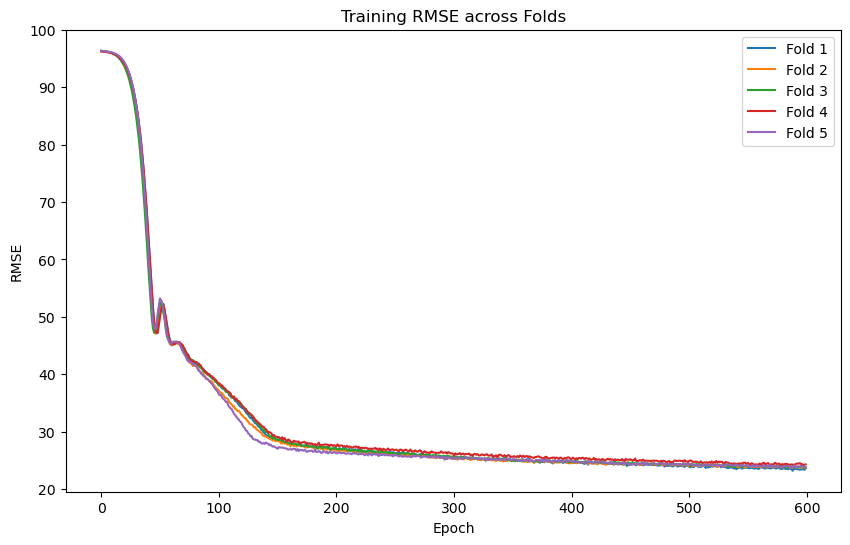

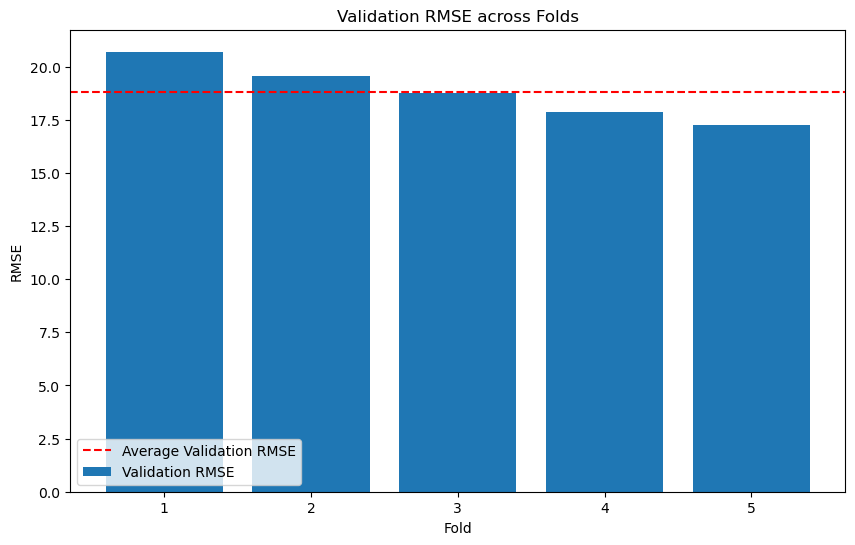

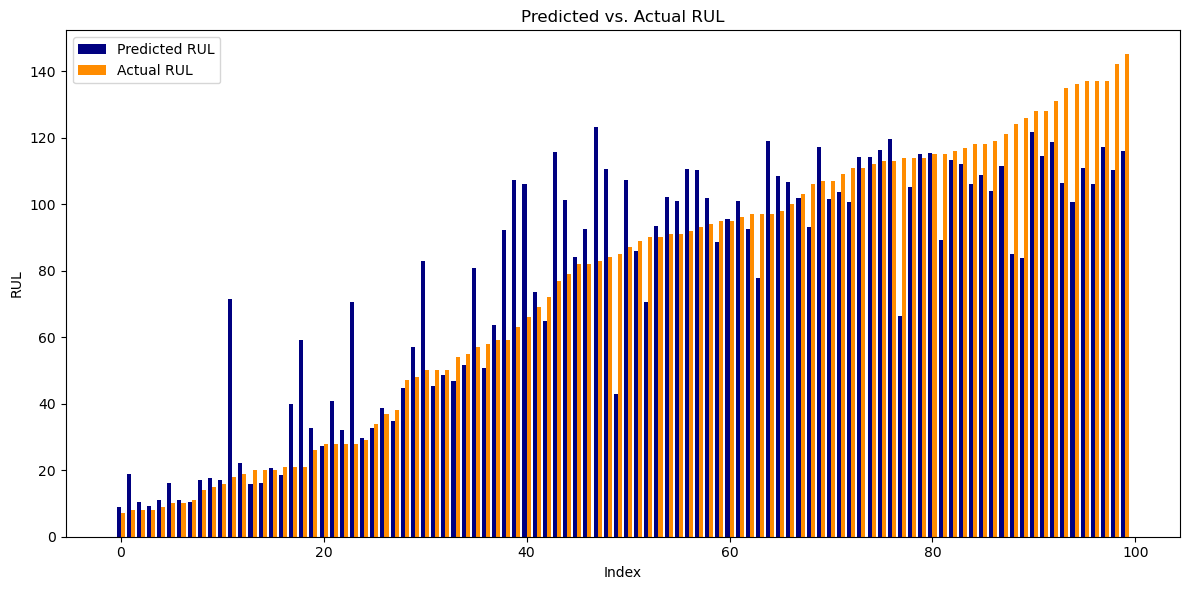

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(len(rmse_values)):
    plt.plot(rmse_values[i], label=f'Fold {i+1}')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training RMSE across Folds')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), test_rmse_values, label='Validation RMSE')
plt.axhline(sum(test_rmse_values) / len(test_rmse_values), color='red', linestyle='--', label='Average Validation RMSE')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Validation RMSE across Folds')
plt.legend(loc='lower left')
plt.show()

pred_flat = predictions.flatten()
x = np.arange(len(pred_flat))
sort_indices = np.argsort(true_test_rul)
true_test_rul_sorted = np.array(true_test_rul)[sort_indices]
pred_flat_sorted = pred_flat[sort_indices]
width = 0.4
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, pred_flat_sorted, width, color='navy', label='Predicted RUL')
plt.bar(x + width/2, true_test_rul_sorted, width, color='darkorange', label='Actual RUL')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.title('Predicted vs. Actual RUL')
plt.legend()
plt.tight_layout()
plt.show()